In [3]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL

from sklearn.linear_model import LinearRegression


In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything()

## Загрузка данных

Работать мы будем  с датасетом Tourism, который содержит данные о количестве туристов в разных странах — https://zenodo.org/records/4656096.

In [5]:
df = pd.read_csv("monash_tourism_monthly.csv")
df.head()

,id,timestamp,target
0,T000000,1979-01-31,1149.8700
1,T000000,1979-02-28,1053.8002
2,T000000,1979-03-31,1388.8798
3,T000000,1979-04-30,1783.3702
4,T000000,1979-05-31,1921.0252


Для рисования графиков будем использовать Plotly. 

Несколько полезных ссылок:
- Вводная статья про Plotly (на русском): https://habr.com/ru/articles/502958/.

- Галерея графиков с примерами кода: https://plotly.com/python/. 
  
- Time Series and Date Axes in Python: https://plotly.com/python/time-series/.

In [6]:
fig = go.Figure()

seed_everything()
random_ids = np.random.choice(df["id"].unique(), 10, replace=False)

for i in random_ids:
    fig.add_trace(
        go.Scatter(x=df[df["id"] == i]["timestamp"], y=df[df["id"] == i]["target"], name=str(i))
    )

fig.update_layout(
    title="10 случайных рядов из Monash Tourism Dataset",
    xaxis_title="Дата",
    yaxis_title="Значение ряда",
)

fig.show()

__`Вопросы:`__

__Что можно сказать про эти временные ряды?__
- Различаются ли ряды между собой?

__Выберите какой-то один ряд и посмотрите на него более подробно.__
- Есть ли в нем тренд (линейный, экспоненциальный или какой-то другой)?
- Есть ли в нем сезонность (аддитивная или мультипликативная)?
- Есть ли в нем точки смены режима (точки, в которых сильно меняется поведение ряда)?
- Есть ли в нем выбросы?

## Разделение на обучающую и тестовую выборки

__`Вопрос:`__ __Почему мы не можем просто использовать случайное разбиение на train и test?__

```python
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, shuffle=True)
```

__`Ответ:`__ 
Мы перемешаем точки одного и того же временного ряда между train и test и потеряем временную структуру данных в принципе. На таком мы не сможем обучить большинство моделей в принципе.

__```Вопрос:```__ __Как изменится наш ответ, если мы уже построили признаки?__

|   | id      | lag_1   | lag_12 | month | year | day | dayofweek |
|---:|---|---|---:|---:|---:|---:|---:|
| 0 | T000000 | NaN | NaN | 1 | 1979 | 31 | 3 |
| 1 | T000000 | 1149.87 | NaN | 2 | 1979 | 28 | 3 |
| 2 | T000000 | 1053.80 | NaN | 3 | 1979 | 31 | 5 |
| ... | ... | ... | ... | ... | ... | ... | ... |

__`Ответ:`__ В таком случае мы позволим модели «заглядывать в будущее» — она сможет обучаться на значениях в те же периоды, что и в тестовой выборке, и это приведет к более оптимистичным оценкам. Обратите внимание, что в нашем случае сезонность мультипликативная, и при неправильном разбиении модель будет не генерализировать этот эффект, а просто запоминать его из обучающей выборки.

__`Вопрос:`__ __Почему, даже убрав shuffle, мы получим неверный результат?__

```python
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, shuffle=False)
```

__`Ответ:`__ У нас есть колонка id, которая обозначает разные временные ряды. А обычный train_test_split просто возьмет первые 80% всех строк для train и последние 20% для test.

Так как ряды невыровненные, то можно пойти двумя путями:
- Если мы хотим иметь предсказания для каждого ряда, то можно разбить каждый ряд по времени на train и test. Однако тогда в test для одного ряда может попасть такой период, который находится в train другого ряда.

- Мы можем ввести "глобальное" разбиение по времени, но тогда для одних рядов может не оказаться точек в test, а для других — в train.

Так как на этом занятии мы рассматриваем ряды независимо друг от друга, то будем использовать первый подход.

In [7]:
train_ts, test_ts = [], []
for ts_id in df["id"].unique():
    ts_data = df[df["id"] == ts_id].sort_values("timestamp")
    split_index = int(len(ts_data) * 0.8)
    train_ts.append(ts_data.iloc[:split_index])
    test_ts.append(ts_data.iloc[split_index:])

train_df = pd.concat(train_ts).reset_index(drop=True)
test_df = pd.concat(test_ts).reset_index(drop=True)

In [8]:
fig = go.Figure()

seed_everything()
random_ids = np.random.choice(df["id"].unique(), 10, replace=False)
colors = px.colors.qualitative.Plotly

for idx, i in enumerate(random_ids):
    color = colors[idx % len(colors)]
    fig.add_trace(
        go.Scatter(
            x=train_df[train_df["id"] == i]["timestamp"],
            y=train_df[train_df["id"] == i]["target"],
            name=f"{i} - train",
            line=dict(color=color),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=test_df[test_df["id"] == i]["timestamp"],
            y=test_df[test_df["id"] == i]["target"],
            name=f"{i} - test",
            line=dict(dash="dash", color=color),
        )
    )

fig.update_layout(
    title="Train и Test выборки для 10 случайных рядов из Monash Tourism Dataset",
    xaxis_title="Дата",
    yaxis_title="Значение ряда",
)
fig.show()

## Метрики

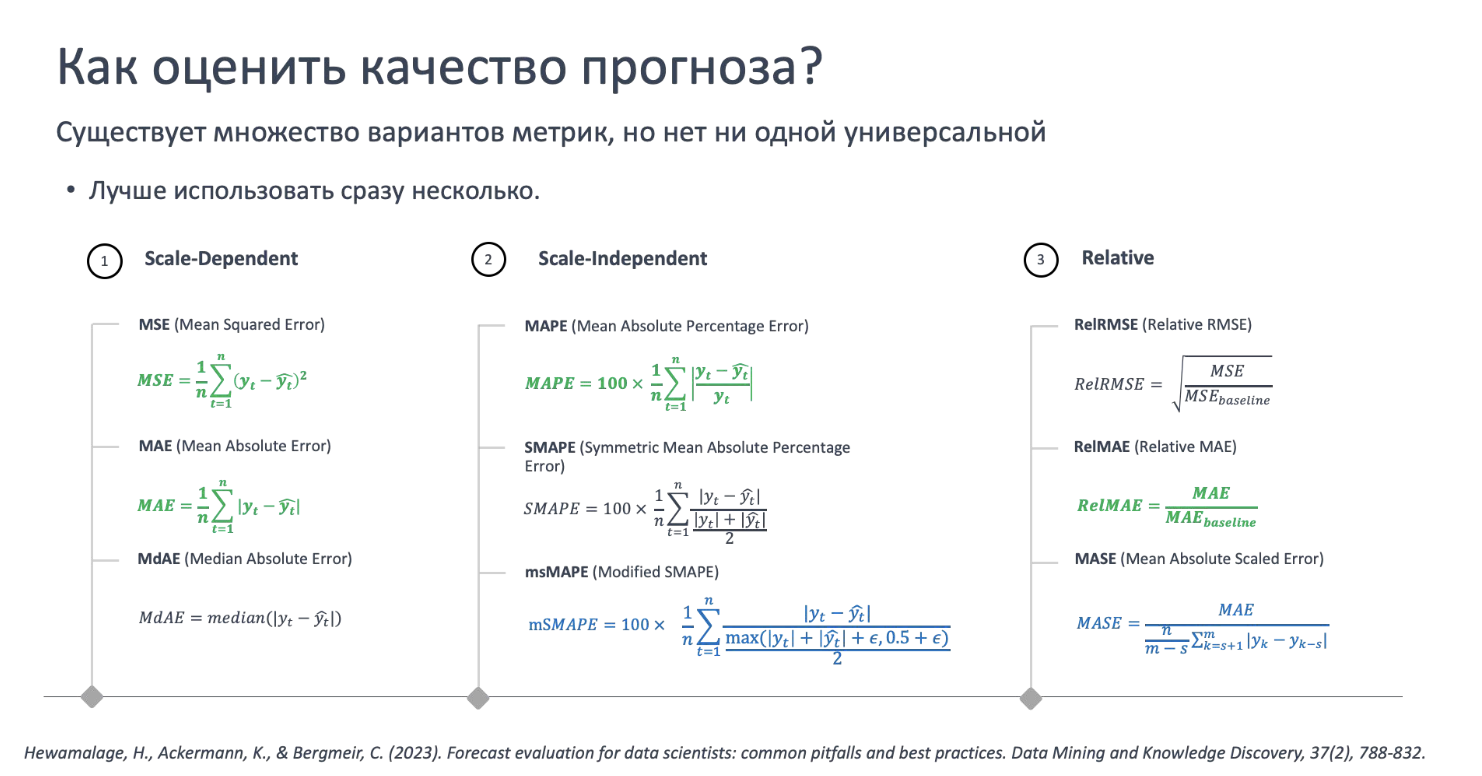

__`Вопрос:`__ __Какие из этих метрик подходят, а какие не подходят для нашей задачи и почему?__

__`Ответ:`__
- Scale-dependent в нашем случае не подходят, так как ряды с большими значениями будут перетягивать на себя метрику. Метрика бы подошла, если бы все ряды были в одном масштабе или если бы у нас был один ряд.
- Scale-independent метрики подходят, но нужно быть осторожным с нулями.
- Relative метрики тоже подходят.

__`Листочек`__: Какие проблемы решает SMAPE и mSMAPE?



### 1. MAPE (Mean Absolute Percentage Error)
**Средняя абсолютная процентная ошибка**

$$MAPE = \frac{100\%}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$

Где:
*   $y_t$ — реальное значение.
*   $\hat{y}_t$ — предсказанное значение.

**Суть:**
Показывает, на сколько процентов в среднем мы ошибаемся относительно реального значения.

**Плюсы (+):**
*   **Интерпретируемость:** Бизнес любит эту метрику. Сказать "мы ошибаемся в среднем на 10%" понятно любому менеджеру.
*   **Масштабируемость:** Можно сравнивать товары с продажами 100 штук и 10 000 штук (так как это проценты).

**Минусы (-):**
1.  **Проблема нуля:** Если реальное значение $y_t = 0$, формула ломается (деление на ноль). В таблице на картинке (строка с $y_t=0$) написано: *"не определена"*.
2.  **Асимметрия штрафа:** MAPE сильнее штрафует за прогноз, который *выше* факта, чем за прогноз, который *ниже* факта (при одинаковой абсолютной ошибке).
    *   *Пример:*
        *   Факт 100, Прогноз 50 (ошибка 50 ед) -> $50/100 = 50\%$.
        *   Факт 50, Прогноз 100 (ошибка 50 ед) -> $50/50 = 100\%$.
    *   Это подталкивает модель занижать прогнозы (bias towards under-forecasting), чтобы минимизировать ошибку.

---

### 2. SMAPE (Symmetric Mean Absolute Percentage Error)
**Симметричная средняя абсолютная процентная ошибка**

$$SMAPE = \frac{100\%}{n} \sum_{t=1}^{n} \frac{|y_t - \hat{y}_t|}{(|y_t| + |\hat{y}_t|) / 2}$$

**Суть:**
В знаменателе теперь не просто факт, а среднее между фактом и прогнозом. Это попытка исправить асимметрию MAPE и проблему деления на ноль.

**Плюсы (+):**
*   **Симметричность:** В таблице видно (строки 2 и 3), что если поменять местами факт и прогноз (50 vs 100), ошибка будет одинаковой — **66,7%**. Это честнее.
*   **Ограниченность:** Значение всегда находится в диапазоне от 0% до 200%.
*   **Работает с нулями:** Если $y_t=0$, но прогноз $\hat{y}_t \neq 0$, метрика не падает, а выдает максимальную ошибку (200%), что логично.

**Минусы (-):**
1.  **"Не совсем проценты":** Как отмечено красным на картинке, деление на полусумму делает интерпретацию сложнее. Это не "процент от факта", это специфическая величина.
2.  **Проблема малых чисел (шум):** Посмотри на последнюю строку таблицы.
    *   Факт: 0.001, Прогноз: 0.002.
    *   Разница мизерная — всего 0.001. Для бизнеса это, скорее всего, одно и то же (шум, пыль).
    *   Но SMAPE выдает **66,7%**. Модель будет тратить огромные усилия, чтобы подогнать 0.001 к 0.002, хотя это не имеет смысла. Это делает обучение нестабильным на данных, близких к нулю.

---

### 3. mSMAPE (Modified SMAPE)
**Модифицированная версия для борьбы с шумом**

Формула на картинке добавляет **порог отсечения** (threshold) в знаменатель:
$$ Знаменатель = \max\left( \frac{|y_t| + |\hat{y}_t| + \epsilon}{2}, \quad 0.5 + \epsilon \right) $$

*(В разных источниках константа 0.5 может меняться, но суть одна).*

**Суть доработки:**
Мы искусственно запрещаем знаменателю становиться слишком маленьким. Мы говорим: "Если числа меньше 0.5, считай их ошибку не относительно их микроскопических значений, а относительно фиксированного порога".

**Какую проблему решает (Ответ на вопрос "Листочка"):**
Она решает проблему **нестабильности SMAPE на малых величинах**.

**Разбор последней строки таблицы (самый важный момент):**
*   Факт ($y$): 0.001
*   Прогноз ($\hat{y}$): 0.002
*   Абсолютная разница: 0.001
*   **SMAPE:** Делит 0.001 на среднее (~0.0015). Получает огромные **66,7%**.
*   **mSMAPE:** Видит, что числа очень мелкие. Срабатывает `max` в знаменателе, и вместо 0.0015 знаменатель становится равным **0.5**.
*   Расчет: $0.001 / 0.5 \approx 0.002$ (или **0.2% - 0.4%** в зависимости от точных коэффициентов).
*   **Итог:** Метрика показывает 0.4%, говоря нам: *"Расслабься, ошибка ничтожная, не обращай внимания"*.

---


| $y_t$ (Факт) | $\hat{y}_t$ (Прогноз) | **MAPE** | **SMAPE** | **mSMAPE** |
| :---: | :---: | :---: | :---: | :---: |
| **100** | **110** | 10% | 9,5% | 9,5% |
| **50** | **100** | 100% | **66,7%** | 66,7% |
| **100** | **50** | 50% | **66,7%** | 66,7% |
| **0** | **2** | *не определена* | 200% | 200% |
| **0,001** | **0,002** | 100% | 66,7% | **0,4%** |



Давайте проверим наличие нулей в наших рядах.

In [9]:
df["target"].value_counts().sort_index()

target
0.0          574
3.0            1
4.0          401
5.0           16
6.0           27
            ... 
1221159.0      1
1238091.0      1
1265519.0      1
1324888.0      1
1364825.0      1
Name: count, Length: 23015, dtype: int64

В качестве упражнения возьмем метрики mSMAPE, RelMAE и MASE для оценки качества наших предсказаний.

In [10]:
def mSMAPE(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    numerator = np.abs(y_true - y_pred)
    denominator = np.maximum(np.abs(y_true) + np.abs(y_pred) + eps, 0.5 + eps) / 2
    msmape = 100 * np.mean(numerator / denominator)

    return msmape

In [11]:
def RelMAE(y_true: np.ndarray, y_pred: np.ndarray, y_naive: np.ndarray) -> float:
    mae_model = np.mean(np.abs(y_true - y_pred))
    mae_naive = np.mean(np.abs(y_true - y_naive))
    relmae = mae_model / mae_naive

    return relmae

In [12]:
def mase(
    y_pred: np.ndarray,
    y_true_insample: np.ndarray,
    y_true_outsample: np.ndarray,
    frequency: int,
) -> float:
    mae_model = np.mean(np.abs(y_true_outsample - y_pred))
    mae_naive = np.mean(np.abs(y_true_insample[:-frequency] - y_true_insample[frequency:]))
    mase = mae_model / mae_naive

    return mase

## Разложение ряда на компоненты с помощью STL и использование простейших моделей

В иллюстративных целях просемплируем один ряд.

In [13]:
random_id = random.choice(df["id"].unique())
random_train_df = train_df[train_df["id"] == random_id]
random_test_df = test_df[test_df["id"] == random_id]

In [14]:
fig = go.Figure()

seed_everything()
color = px.colors.qualitative.Plotly[0]


fig.add_trace(
    go.Scatter(
        x=train_df[train_df["id"] == random_id]["timestamp"],
        y=train_df[train_df["id"] == random_id]["target"],
        name=f"{random_id} - train",
        line=dict(color=color),
    )
)
fig.add_trace(
    go.Scatter(
        x=test_df[test_df["id"] == random_id]["timestamp"],
        y=test_df[test_df["id"] == random_id]["target"],
        name=f"{random_id} - test",
        line=dict(dash="dash", color=color),
    )
)

fig.update_layout(
    title="Train и Test выборки для случайного ряда из Monash Tourism Dataset",
    xaxis_title="Дата",
    yaxis_title="Значение ряда",
)
fig.show()

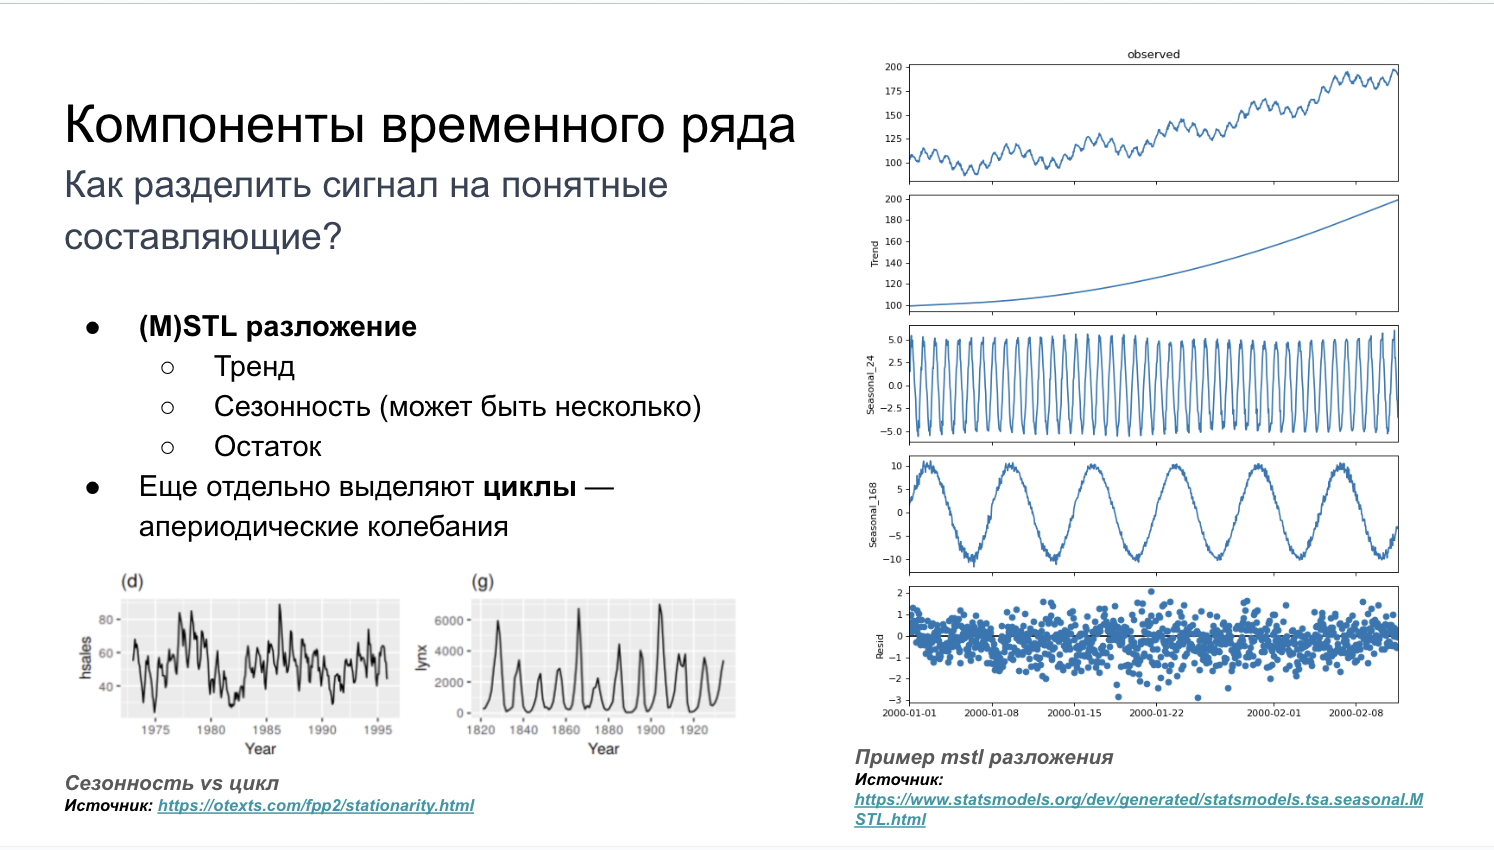

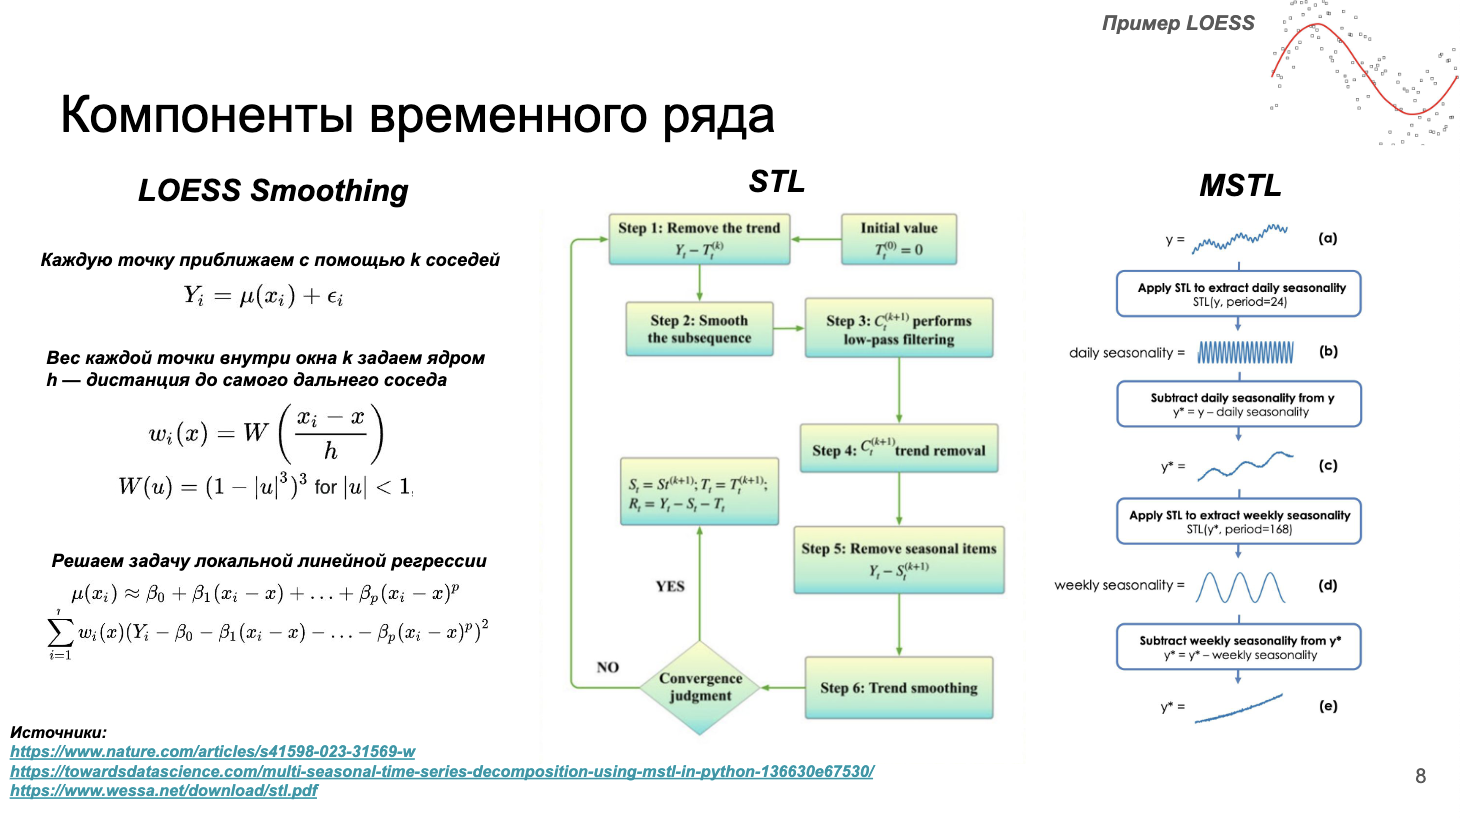

Попробуем выделить явно тренд и сезонность при помощи STL разложения — https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html.

Материалы, которые лучше позволят понять отдельные компоненты STL разложения:
- Алгоритм LOWESS (на русском): http://www.machinelearning.ru/wiki/index.php?title=Алгоритм_LOWESS
  
- Ядровые функции (на русском): http://www.machinelearning.ru/wiki/index.php?title=Ядерное_сглаживание
  
- Метод наименьших квадратов (на русском): https://books.econ.msu.ru/Introduction-to-Econometrics/chap02/2.2/ 

- Метод наименьших квадратов в матричной форме (на русском): https://books.econ.msu.ru/Introduction-to-Econometrics/chap03/3.3/ 
  
- Основные методы декомпозиции и их сравнение: https://otexts.com/fpp3/decomposition.html

Сначала разберемся с тем, как считаем веса для наших точек.

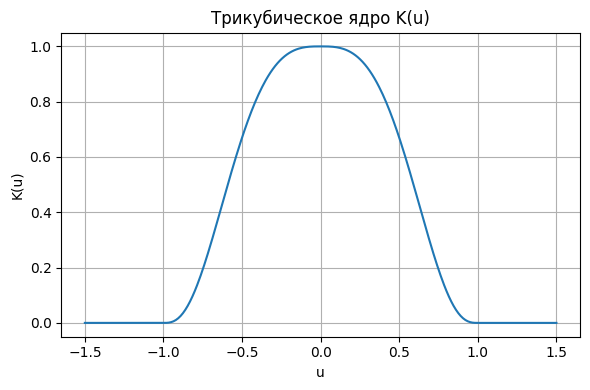

In [15]:
def tricube_kernel(u: np.ndarray) -> np.ndarray:
    k = np.zeros_like(u)
    mask = np.abs(u) <= 1
    k[mask] = (1 - np.abs(u[mask])**3) ** 3
    return k


u = np.linspace(-1.5, 1.5, 400)
k = tricube_kernel(u)

plt.figure(figsize=(6, 4))
plt.plot(u, k)
plt.title("Трикубическое ядро K(u)")
plt.xlabel("u")
plt.ylabel("K(u)")
plt.grid(True)
plt.tight_layout()
plt.show()

__`Вопрос:`__ __STL разложение требует указания периода. Как его выбрать, исходя из данных?__

Давайте реализуем STL разложение.

Начнем мы с LOESS.

### Зачем вообще нужны методы сглаживания?

В анализе данных и ML мы всегда боремся с одной фундаментальной проблемой:
$$Y = f(X) + \varepsilon$$
Где:
*   $f(X)$ — это **сигнал** (истинная закономерность, тренд, физический закон).
*   $\varepsilon$ (эпсилон) — это **шум** (ошибки измерения, случайные выбросы, человеческий фактор).

**Задачи сглаживания:**

1.  **Выделить сигнал из шума.** Человеческий глаз (и простые модели) могут запутаться в «зубьях пилы» графика. Сглаживание убирает случайные колебания, оставляя главный тренд.
2.  **Заполнить пробелы.** Если данные разреженные, сглаживание позволяет обоснованно предположить, что находится между точками.
3.  **Визуализация.** Чтобы на графике акций увидеть тренд роста компании за год, а не пугаться скачков цены каждую минуту.

---


### **Суть метода LOESS (Locally Estimated Scatterplot Smoothing):**

Это метод непараметрической регрессии, который строит кривую точку за точкой. Алгоритм для каждой точки $x_i$, в которой мы хотим найти сглаженное значение:

1.  **Выбор окна:** Мы берем $k$ ближайших соседей вокруг точки $x_i$. Количество соседей определяется параметром `span` (или `frac`) — чем шире окно, тем более гладкая (и менее гибкая) получается линия.
2.  **Расчет весов:** Каждому соседу присваивается вес в зависимости от расстояния до $x_i$. Сама точка $x_i$ имеет максимальный вес, далекие соседи — минимальный. Обычно используется «колоколообразная» функция (Tricube weight function).
3.  **Локальная регрессия:** На основе этих соседей строится полином низкой степени (обычно прямая или парабола), минимизирующий **Взвешенную среднеквадратичную ошибку (Weighted MSE)**. Точки с большим весом (близкие к центру) сильнее «притягивают» к себе линию.
4.  **Результат:** Из полученной локальной линии берется значение **только** для текущей точки $x_i$. Это и есть $y_{smooth}$.
5.  Процесс повторяется для следующей точки.

**Коротко плюсы:** LOESS шикарен тем, что не заставляет данные ложиться в одну глобальную формулу (как обычная линейная регрессия), а подстраивается под данные локально везде, где нужно.

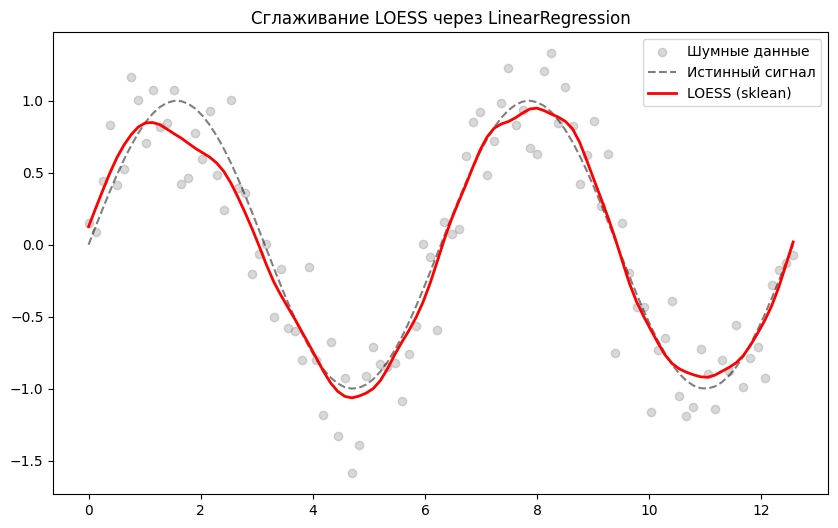

In [16]:
def loess_1d_for_regular_ts(
    y: np.ndarray, num_local_points: int = 7, degree: int = 1
) -> np.ndarray:
    """
    LOESS реализация через sklearn.
    Понятнее, так как скрывает матричные вычисления.
    """
    assert num_local_points % 2 == 1, "Окно должно быть нечетным"

    n = len(y)
    y_smooth = np.zeros(n)

    # Модель регрессии из sklearn
    # fit_intercept=True позволяет модели самой искать "beta_0" (смещение)
    model = LinearRegression(fit_intercept=True)

    half_window = num_local_points // 2

    for i in range(n):
        # 1. Определение границ окна
        left = max(0, i - half_window)
        right = min(n, i + half_window + 1)

        # Выделяем локальные y
        y_local = y[left:right]

        # Выделяем локальные X.
        # Важно: для локальной регрессии удобнее считать, что
        # текущая точка i имеет координату 0.
        # Соседи будут иметь координаты -3, -2, -1, 0, 1, 2, 3 и т.д.
        # Это повышает численную стабильность.
        X_ids = np.arange(left, right) - i
        X_local = X_ids.reshape(-1, 1) # Sklearn требует 2D массив (n_samples, n_features)

        # Если нужна полиномиальная регрессия (парабола), добавляем x^2
        if degree > 1:
            # Для degree=2 добавляем столбец квадратов: [x, x^2]
            X_local = np.hstack([X_local, X_local ** degree])

        # 2. Расчет весов (Ядро Tricube)
        # Точки далеко от центра i получают вес близкий к 0
        distances = np.abs(X_ids)
        max_dist = np.max(distances) + 1e-8 # защита от деления на 0
        u = distances / max_dist
        weights = (1 - u**3)**3

        # 3. Магия Sklearn
        if degree == 0:
            # Degree 0 — это просто взвешенное среднее.
            # Можно через регрессию на константу, но проще формулой:
            y_smooth[i] = np.average(y_local, weights=weights)
        else:
            # Обучаем линейную регрессию на маленьком кусочке данных
            # с учетом весов!
            model.fit(X_local, y_local, sample_weight=weights)

            # 4. Предсказание
            # Нам нужно значение в центре окна, то есть там, где наш локальный X равен 0
            prediction_point = np.zeros((1, X_local.shape[1]))
            y_smooth[i] = model.predict(prediction_point)[0]

    return y_smooth

# --- Пример использования ---

# Генерируем шумный синус
x = np.linspace(0, 4 * np.pi, 100)
y_true = np.sin(x)
y_noisy = y_true + np.random.normal(0, 0.3, size=len(x))

# Применяем LOESS
y_loess = loess_1d_for_regular_ts(y_noisy, num_local_points=15, degree=1)

# Рисуем
plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, alpha=0.3, label='Шумные данные', color='gray')
plt.plot(x, y_true, 'k--', label='Истинный сигнал', alpha=0.5)
plt.plot(x, y_loess, 'r-', linewidth=2, label='LOESS (sklean)')
plt.legend()
plt.title("Сглаживание LOESS через LinearRegression")
plt.show()


In [17]:
y = np.array([1.0, 2.0, 4.0, 3.0, 1.0])
y_smooth = loess_1d_for_regular_ts(y, num_local_points=5, degree=1)
print(y_smooth)

[1.         2.28631052 3.14106845 2.71368948 1.        ]


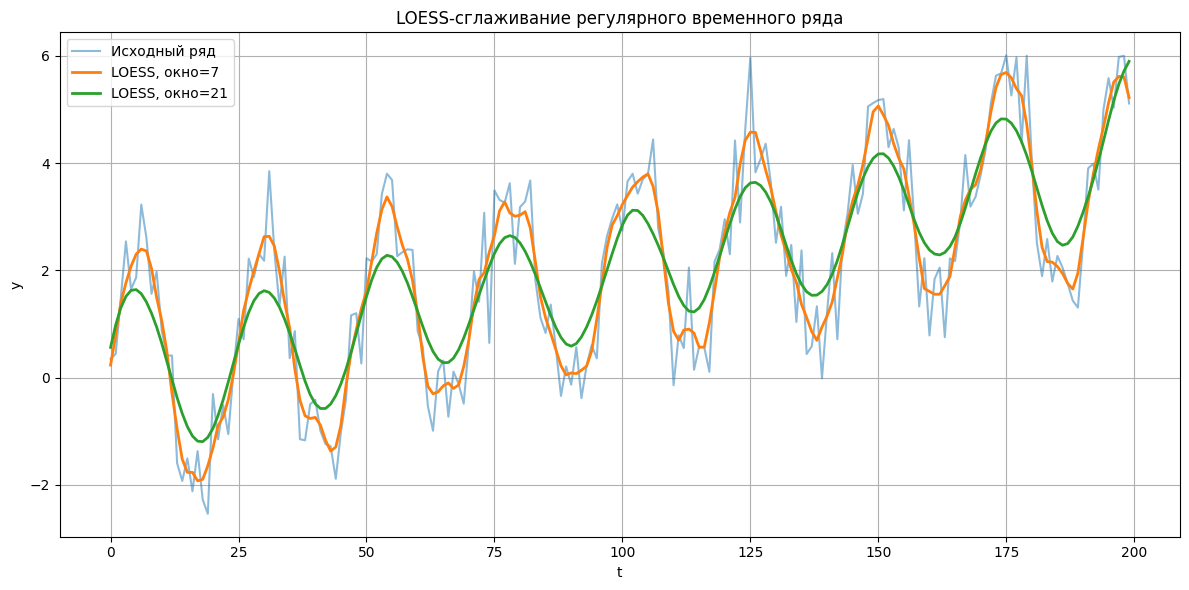

In [18]:
seed_everything()

# Сгенерируем синтетический временной ряд
n = 200
t = np.arange(n)
trend_true = 0.02 * t
season_true = 2 * np.sin(2 * np.pi * t / 24)
noise = np.random.normal(scale=0.7, size=n)
y = trend_true + season_true + noise

# Сглаживание с разными размерами окна
y_smooth_7 = loess_1d_for_regular_ts(y, num_local_points=7, degree=1)
y_smooth_21 = loess_1d_for_regular_ts(y, num_local_points=21, degree=1)

plt.figure(figsize=(12, 6))

plt.plot(t, y, label="Исходный ряд", alpha=0.5)

plt.plot(t, y_smooth_7, label="LOESS, окно=7", linewidth=2)
plt.plot(t, y_smooth_21, label="LOESS, окно=21", linewidth=2)

plt.title("LOESS-сглаживание регулярного временного ряда")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Теперь собираем функции для сглаживания тренда и сезонности.

In [19]:
def estimate_trend_loess(y: np.ndarray, num_local_points: int = 7, degree: int = 1) -> np.ndarray:
    trend = loess_1d_for_regular_ts(y, num_local_points=num_local_points, degree=degree)
    return trend


def lowpass_loess(y: np.ndarray, num_local_points: int, degree: int = 1) -> np.ndarray:
    return loess_1d_for_regular_ts(y, num_local_points=num_local_points, degree=degree)


def estimate_seasonal_loess(
    y_detrended: np.ndarray, period: int, num_local_points: int = 7, degree: int = 1
) -> np.ndarray:
    n = len(y_detrended)

    seasonal = np.zeros(n, dtype=float)

    # Для каждой фазы сезона (0, 1, ..., period-1) берем подпоследовательность и сглаживаем ее
    for phase in range(period):
        idx = np.arange(phase, n, period)
        y_sub = y_detrended[idx]
        y_sub_smooth = loess_1d_for_regular_ts(
            y_sub, num_local_points=num_local_points, degree=degree
        )

        seasonal[idx] += y_sub_smooth

    return seasonal

Наконец, собираем STL пайплайн.

# STL
**STL** расшифровывается как **S**easonal-**T**rend decomposition using **L**OESS.

Давай разберем этот код буквально по винтикам. Это реализация классического алгоритма STL.

Чтобы понять общую картину: **мы пытаемся разделить сложный сигнал на три чистых компонента:**
$$Y = Trend + Seasonality + Noise$$

Но мы не знаем ни тренда, ни сезонности. Поэтому мы используем тактику **последовательного улучшения** (итераций).

Давай сначала разберем **вспомогательные функции**, потому что в них — вся соль, а потом перейдем к главному циклу.

---

### 1. `estimate_seasonal_loess` — Самая хитрая функция
```python
def estimate_seasonal_loess(y_detrended, period, ...):
    ...
    for phase in range(period):
        idx = np.arange(phase, n, period)
        y_sub = y_detrended[idx]
        ...
```
**Что здесь происходит?**
Это техника, называемая **Cycle-Subseries Smoothing**.
Представь, что у тебя данные продаж по месяцам за 10 лет. `period = 12`.
Вместо того чтобы смотреть на временной ряд целиком, мы "разрезаем" его на 12 независимых рядов:
1.  **Ряд №1 (phase=0):** Только Январи (Янв 2000, Янв 2001, Янв 2002...).
2.  **Ряд №2 (phase=1):** Только Феврали.
3.  ... и так далее.

Команда `idx = np.arange(phase, n, period)` берет индексы с шагом 12.

**Зачем мы это делаем?**
Мы применяем LOESS **отдельно к каждому месяцу**.
*  Это позволяет отфильтрровать шум и Смоделировать плавное изменение:
*   Это позволяет понять, как меняется поведение *конкретно января* с годами.
*   Например: "В 2000-м в январе покупали мало, а к 2010-му в январе стали покупать много".
*   LOESS нарисует плавную кривую изменения "силы января".

**Итог функции:** Она возвращает `seasonal` — массив той же длины, что и исходный, где для каждой точки записано: "Какая была обычная сезонная добавка в этом месяце в этот год".

---

### 2. `stl_decompose` — Главный цикл

Здесь мы запускаем итерации (`n_iter`), чтобы уточнить наши догадки.

**Инициализация:**
```python
trend = np.zeros(n)
seasonal = np.zeros(n)
```
Сначала мы притворяемся дурачками: "Тренда нет, Сезонности нет".

#### Step 1: Remove the trend (Снятие тренда)
```python
y_detrended = y - trend
```
*   **Итерация 1:** Мы вычитаем 0. `y_detrended` — это просто исходный ряд `y`.
*   **Итерация 2:** Мы вычитаем тренд, который нашли на прошлой итерации. Теперь в `y_detrended` осталось только `Сезонность + Шум`.

#### Step 2: Smooth the subsequence (Поиск "сырой" сезонности)
```python
seasonal_raw = estimate_seasonal_loess(y_detrended, ...)
```
Здесь мы запускаем ту самую функцию "по месяцам", которую разобрали выше.
Мы говорим: "Посмотри на ряд без тренда. Найди, как ведут себя Январи, как Феврали...".
Получаем `seasonal_raw` (Сырая сезонность).

**В чем проблема на этом шаге? (Почему она "Raw" / Сырая?)**
Так как на 1-й итерации мы вычли `trend=0` (которого на самом деле там много), весь Тренд исходного ряда попал в `y_detrended`.
Функция порезки на месяцы могла ошибочно принять Тренд за Сезонность.
*Пример:* Продажи растут весь год. А функция думает: "О, Январи растут, Феврали растут... Наверное, это у них сезонность такая раздутая".
В итоге среднее значение `seasonal_raw` не равно нулю, оно плавает вместе с трендом.

#### Step 3: Low-pass filtering (Фильтр низких частот)
```python
seasonal_lowpassed = lowpass_loess(seasonal_raw, ...)
```
Это работа над ошибками Шага 2.
Мы берем нашу "Сырую сезонность" и очень жестко её сглаживаем.
`lowpass` использует огромное окно (обычно больше, чем длинна года).
*   **Задача:** Найти то общее движение, которое есть во всех месяцах сразу.
*   Если `seasonal_raw` в среднем равен +1000, значит, туда "протёк" Тренд. `lowpass` найдет эти +1000.

#### Step 4: Trend removal (Очистка сезонности)
```python
seasonal = seasonal_raw - seasonal_lowpassed
```
Мы вычитаем найденную "утечку тренда".
Теперь `seasonal` колеблется строго вокруг нуля (сумма плюсов и минусов за год $\approx$ 0).
Это **Чистая Сезонность**.

#### Step 5: Remove seasonal items (Десезонализация)
```python
y_deseasonal = y - seasonal
```
Теперь, когда у нас есть отличная Чистая Сезонность, мы вычитаем её из самого **исходного** ряда `y`.
Что осталось?
$$ (Trend + Seasonality + Noise) - Seasonality = Trend + Noise $$

#### Step 6: Trend smoothing (Поиск тренда)
```python
trend = estimate_trend_loess(y_deseasonal, ...)
```
Мы применяем LOESS к ряду без сезонности.
Так как "зубчиков" (сезонных скачков) больше нет, LOESS может спокойно нарисовать красивую плавную линию глобального тренда.

Этот новый `trend` мы берем и несем в начало цикла (**Step 1**) на следующую итерацию.

---

### Зачем нужны итерации (`n_iter`)?

Это процесс дистилляции.

1.  В начале мы не знали Тренд, поэтому Сезонность (Step 2) получилась с грязью (смешалась с трендом).
2.  Мы почистили Сезонность (Step 3-4).
3.  Раз Сезонность стала чище, мы лучше очистили исходный ряд (Step 5).
4.  Раз исходный ряд чище, мы точнее нашли Тренд (Step 6).
5.  **Следующий круг:** Раз Тренд точнее, мы в Step 1 лучше очистим данные для поиска Сезонности...

Обычно через 2 круга (`n_iter=2`) результаты перестают меняться.

### Итог по аргументам функции

*   `seasonal_num_local_points`: Насколько быстро может меняться сезонность? (Маленькое число = Январи 2000 и 2002 могут сильно отличаться. Большое число = Январи меняются очень медленно, консервативно).
*   `trend_num_local_points`: Насколько гибок глобальный тренд? (Маленькое число = Тренд реагирует на каждый экономический кризис. Большое число = Тренд показывает только глобальное направление десятилетия).
*   `lowpass_num_local_points`: Обычно ставится очень большим (чуть больше одного года), чтобы поймать только самые медленные "утечки" тренда.

In [20]:
def stl_decompose(
    y: np.ndarray,
    period: int,
    seasonal_num_local_points: int = 7,
    trend_num_local_points: int = 7,
    n_iter: int = 2,
    seasonal_degree: int = 1,
    trend_degree: int = 1,
    lowpass_num_local_points: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Step 1: Remove the trend          -> y_detrended = y - T^(k)
    Step 2: Smooth the subsequence    -> S_raw_t
    Step 3: Low-pass filtering        -> C_t = lowpass(S_raw_t)
    Step 4: Trend removal             -> S_t = S_raw_t - C_t
    Step 5: Remove seasonal items     -> y_deseasonal = y - S_t
    Step 6: Trend smoothing           -> T^(k+1)_t
    """
    y = np.asarray(y, dtype=float)
    n = len(y)

    if lowpass_num_local_points is None:
        lowpass_num_local_points = max(7, 3 * period)
        if lowpass_num_local_points % 2 == 0:
            lowpass_num_local_points += 1

    # Инициализация: тренд = 0, сезонность = 0
    trend = np.zeros(n, dtype=float)
    seasonal = np.zeros(n, dtype=float)

    for _ in range(n_iter):
        # Step 1: Remove the trend          -> y_detrended = y - T^(k)
        y_detrended = y - trend

        # Step 2: Smooth the subsequence    -> S_raw_t
        seasonal_raw = estimate_seasonal_loess(
            y_detrended,
            period=period,
            num_local_points=seasonal_num_local_points,
            degree=seasonal_degree,
        )

        # Step 3: Low-pass filtering        -> C_t = lowpass(S_raw_t)
        seasonal_lowpassed = lowpass_loess(
            seasonal_raw, num_local_points=lowpass_num_local_points, degree=seasonal_degree
        )

        # Step 4: Trend removal             -> S_t = S_raw_t - C_t
        seasonal = seasonal_raw - seasonal_lowpassed

        # Step 5: Remove seasonal items     -> y_deseasonal = y - S_t
        y_deseasonal = y - seasonal

        # Step 6: Trend smoothing           -> T^(k+1)_t
        trend = estimate_trend_loess(
            y_deseasonal, num_local_points=trend_num_local_points, degree=trend_degree
        )

    # Остаток
    remainder = y - trend - seasonal

    return trend, seasonal, remainder

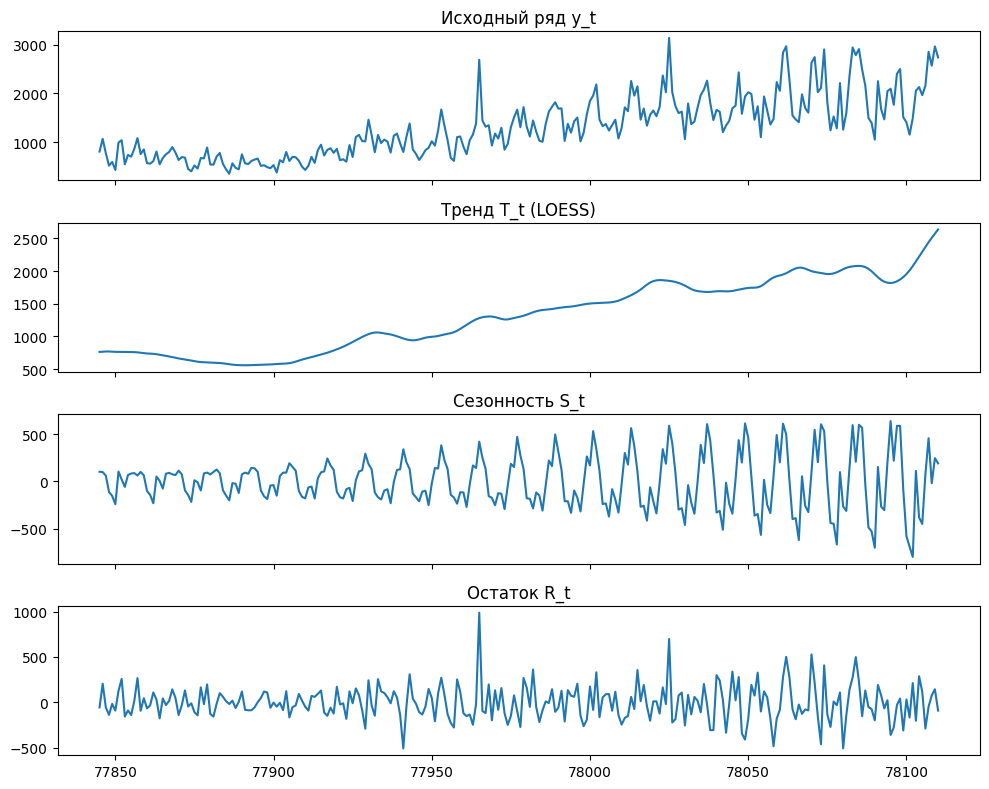

In [25]:
seed_everything()

PERIOD = 12
y = random_train_df["target"].to_numpy()
t = random_train_df.index.to_numpy()

# STL-разложение
trend_num_local_points = int(1.5 * PERIOD / (1 - 1.5 / PERIOD)) + 1

trend, seasonal, remainder = stl_decompose(
    y,
    period=12,
    seasonal_num_local_points=25,
    trend_num_local_points=trend_num_local_points,
    n_iter=2,
    seasonal_degree=1,
    trend_degree=1,
    lowpass_num_local_points=None,
)

# Визуализация
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, y)
axes[0].set_title("Исходный ряд y_t")

axes[1].plot(t, trend)
axes[1].set_title("Тренд T_t (LOESS)")

axes[2].plot(t, seasonal)
axes[2].set_title("Сезонность S_t")

axes[3].plot(t, remainder)
axes[3].set_title("Остаток R_t")

plt.tight_layout()
plt.show()

Сравним нашу реализацию с той, что имплементирована в `statsmodels`.

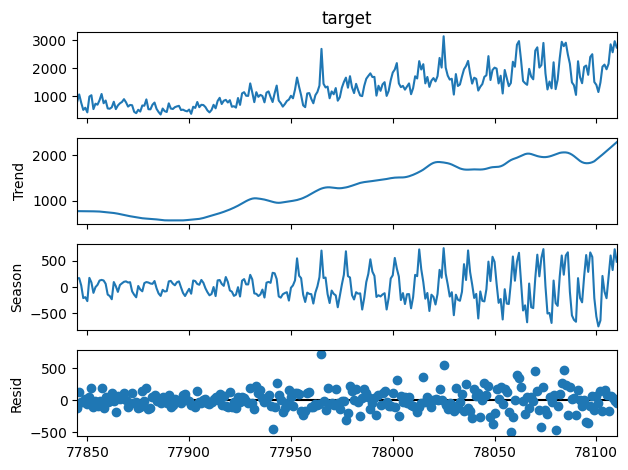

In [33]:
PERIOD = 12

res = STL(random_train_df["target"], period=PERIOD).fit()
res.plot()
plt.show()

STL-разложение можно использовать для того, чтобы затем строит пайплайны моделей на основое получившихся компонент.

Так, можно тренд и сезонность предсказать простыми моделями, а затем результаты сложить. Остатки можно приблизить ARMA-моделью.

Попробуем сделать первую часть, а именно: построим прогноз тренда методом простого экспоненциального сглаживания, сезонность – наивным повторением последнего цикла, а итоговый прогноз будем считать как сумму тренда и сезонности.

In [108]:
HORIZON = len(random_test_df)

# Генерируем индекс для прогноза
freq = pd.infer_freq(random_train_df["timestamp"])
start = pd.to_datetime(random_train_df["timestamp"].values[-1]) + pd.tseries.frequencies.to_offset(
    freq
)
forecast_index = pd.date_range(start=start, periods=HORIZON, freq=freq)

# Прогноз тренда методом простого экспоненциального сглаживания
trend = res.trend.dropna()
model_trend = SimpleExpSmoothing(trend.to_numpy()).fit()
trend_fc = model_trend.forecast(HORIZON)

# Наивный сезонный прогноз
seasonal = res.seasonal
last_season = seasonal.iloc[-PERIOD:]
seasonal_vals = np.tile(last_season.values, int(np.ceil(HORIZON / PERIOD)))[:HORIZON]
seasonal_fc = pd.Series(seasonal_vals, index=forecast_index)

# Суммируем компоненты и собираем итоговый прогноз
forecast_df = pd.DataFrame({"trend": trend_fc, "seasonal": seasonal_fc})
forecast_df["forecast"] = forecast_df["trend"] + forecast_df["seasonal"]

In [109]:
forecast_df.head()

,trend,seasonal,forecast
2002-03-31,2291.995374,-210.212403,2081.782970
2002-04-30,2291.995374,-561.174117,1730.821256
2002-05-31,2291.995374,-750.120223,1541.875151
2002-06-30,2291.995374,-637.061150,1654.934224
2002-07-31,2291.995374,211.551885,2503.547259


In [110]:
predictions = pd.DataFrame({"date": forecast_df.index, "value": forecast_df["forecast"]})
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=random_train_df["timestamp"], y=random_train_df["target"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=random_test_df["timestamp"], y=random_test_df["target"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=predictions["date"], y=predictions["value"], name="Predictions", line=dict(color="green")
    )
)
fig.update_layout(
    title="Train/Test Split with Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

Давайте вспомним про наши метрики.

In [112]:
print("mSMAPE:", mSMAPE(random_test_df["target"].to_numpy(), forecast_df["forecast"].to_numpy()))

naive_forecast = random_train_df["target"].to_numpy()[-1:]
naive_forecast = np.tile(naive_forecast, int(np.ceil(HORIZON / 1)))
print(
    "RelMAE:",
    RelMAE(
        random_test_df["target"].to_numpy(),
        forecast_df["forecast"].to_numpy(),
        naive_forecast[:HORIZON],
    ),
)

print(
    "MASE:",
    mase(
        forecast_df["forecast"].to_numpy(),
        random_train_df["target"].to_numpy(),
        random_test_df["target"].to_numpy(),
        frequency=PERIOD,
    ),
)

mSMAPE: 16.334360829202677
RelMAE: 0.6353260279473979
MASE: 1.6445016685943206


Давайте сравним с наивной моделью и сезонной наивной моделью.

In [126]:
seasonal_naive_forecast = random_train_df["target"].to_numpy()[-PERIOD:]
seasonal_naive_forecast = np.tile(seasonal_naive_forecast, int(np.ceil(HORIZON / PERIOD)))[:HORIZON]

In [127]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=random_train_df["timestamp"], y=random_train_df["target"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=random_test_df["timestamp"], y=random_test_df["target"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=predictions["date"], y=seasonal_naive_forecast, name="Seasonal Naive Forecast", line=dict(color="green")
    )
)
fig.add_trace(
    go.Scatter(
        x=predictions["date"], y=naive_forecast, name="Naive Forecast", line=dict(color="orange")
    )
)
fig.update_layout(
    title="Train/Test Split with Predictions", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

In [ ]:
pd.DataFrame(
    {
        "Model": ["Decomposition + SES + Seasonal Naive", "Naive", "Seasonal Naive"],
        "mSMAPE": [
            mSMAPE(random_test_df["target"].to_numpy(), forecast_df["forecast"].to_numpy()),
            mSMAPE(random_test_df["target"].to_numpy(), naive_forecast[:HORIZON]),
            mSMAPE(random_test_df["target"].to_numpy(), seasonal_naive_forecast),
        ],
        "RelMAE": [
            RelMAE(
                random_test_df["target"].to_numpy(),
                forecast_df["forecast"].to_numpy(),
                naive_forecast[:HORIZON],
            ),
            RelMAE(
                random_test_df["target"].to_numpy(),
                naive_forecast[:HORIZON],
                naive_forecast[:HORIZON],
            ),
            RelMAE(
                random_test_df["target"].to_numpy(),
                seasonal_naive_forecast,
                naive_forecast[:HORIZON],
            ),
        ],
        "MASE": [
            mase(
                forecast_df["forecast"].to_numpy(),
                random_train_df["target"].to_numpy(),
                random_test_df["target"].to_numpy(),
                frequency=PERIOD,
            ),
            mase(
                naive_forecast[:HORIZON],
                random_train_df["target"].to_numpy(),
                random_test_df["target"].to_numpy(),
                frequency=PERIOD,
            ),
            mase(
                seasonal_naive_forecast,
                random_train_df["target"].to_numpy(),
                random_test_df["target"].to_numpy(),
                frequency=PERIOD,
            ),
        ],
    }
)

,Model,mSMAPE,RelMAE,MASE
0,Decomposition + SES + Seasonal Naive,16.334361,0.635326,1.644502
1,Naive,25.545128,1.000000,2.588437
2,Seasonal Naive,24.541105,0.868749,2.248703
